In [1]:
# Upload the two CSV
trades_path = "/content/historical_data.csv"
sent_path = "/content/fear_greed_index.csv"

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
trades = pd.read_csv(trades_path)
sent = pd.read_csv(sent_path)
trades.columns = trades.columns.str.strip()
sent.columns = sent.columns.str.strip()

print("Trades rows:", len(trades))
print("Sentiment rows:", len(sent))
print("\nTrades columns:", trades.columns.tolist())
print("\nSent sample:")
display(trades.head())
print("\nSentiment sample:")
display(sent.head())


Trades rows: 211224
Sentiment rows: 2644

Trades columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sent sample:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment sample:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


**Parse timestamps & create date columns**

In [4]:
# Trades: try 'Timestamp IST' first
if 'Timestamp IST' in trades.columns:
    trades['timestamp_parsed'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce')
elif 'Timestamp' in trades.columns:
    trades['timestamp_parsed'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')
else:
    trades['timestamp_parsed'] = pd.NaT

trades['date'] = trades['timestamp_parsed'].dt.date

# Sentiment: parse date column (or timestamp)
if 'date' in sent.columns and sent['date'].dtype == object:
    sent['date'] = pd.to_datetime(sent['date'], errors='coerce').dt.date
elif 'timestamp' in sent.columns:
    sent['date'] = pd.to_datetime(sent['timestamp'], unit='s', errors='coerce').dt.date

# Normalize sentiment columns names
if 'classification' in sent.columns:
    sent = sent.rename(columns={'classification':'sentiment'})
if 'value' in sent.columns:
    sent = sent.rename(columns={'value':'sentiment_score'})

print("Parsed trade date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", sent['date'].min(), "to", sent['date'].max())


Parsed trade date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


**Merge trades with sentiment (by date)**

In [5]:
# keep one sentiment entry per date
sent_daily = sent[['date','sentiment','sentiment_score']].drop_duplicates(subset=['date'])
merged = trades.merge(sent_daily, on='date', how='left')
print("Merged rows:", len(merged))
display(merged[['Account','Coin','date','sentiment','sentiment_score','Closed PnL']].head())


Merged rows: 211224


,Account,Coin,date,sentiment,sentiment_score,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80.0,0.0


**Detect PnL column & convert numeric**

In [6]:
pnl_col = None
for c in merged.columns:
    if 'pnl' in c.lower():
        pnl_col = c
        break
print("Detected PnL column:", pnl_col)
if pnl_col:
    merged[pnl_col] = pd.to_numeric(merged[pnl_col], errors='coerce')


Detected PnL column: Closed PnL


**Save merged CSV (required)**

In [7]:
os.makedirs("csv_files", exist_ok=True)
merged.to_csv("csv_files/merged_trades_sentiment.csv", index=False)
print("Saved: csv_files/merged_trades_sentiment.csv")

Saved: csv_files/merged_trades_sentiment.csv


**EDA summaries (tables)**

In [8]:
# PnL by sentiment
if pnl_col:
    pnl_by_sent = merged.groupby('sentiment')[pnl_col].agg(['count','mean','median','std']).reset_index().sort_values('count', ascending=False)
    display(pnl_by_sent)
else:
    print("PnL column not detected. Check column names.")
# Top coins
if 'Coin' in merged.columns:
    display(merged['Coin'].value_counts().head(10))


,sentiment,count,mean,median,std
2,Fear,61837,54.290400,0.0,935.355438
3,Greed,50303,42.743559,0.0,1116.028390
1,Extreme Greed,39992,67.892861,0.0,766.828294
4,Neutral,37686,34.307718,0.0,517.122220
0,Extreme Fear,21400,34.537862,0.0,1136.056091


,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
FARTCOIN,4650
MELANIA,4428
PURR/USDC,2774
WLD,1983


**Plots (save to outputs/)**

<Figure size 800x500 with 0 Axes>

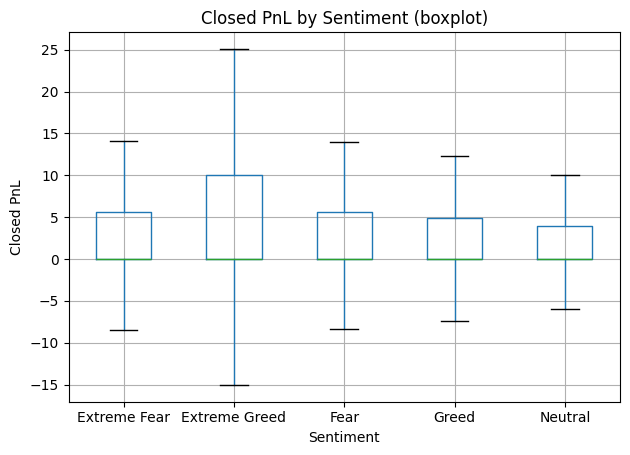

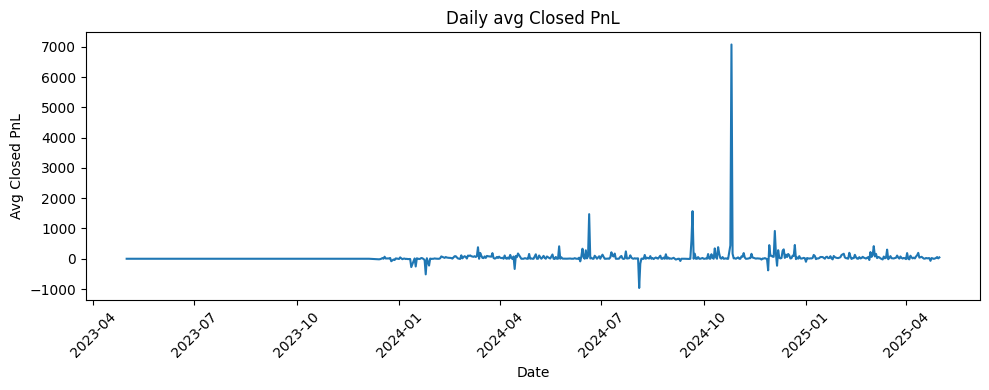

In [9]:
os.makedirs("outputs", exist_ok=True)
# Boxplot PnL by sentiment
if pnl_col and 'sentiment' in merged.columns:
    plt.figure(figsize=(8,5))
    merged.boxplot(column=pnl_col, by='sentiment', showfliers=False)
    plt.title('Closed PnL by Sentiment (boxplot)')
    plt.suptitle('')
    plt.xlabel('Sentiment')
    plt.ylabel('Closed PnL')
    plt.tight_layout()
    plt.savefig("outputs/boxplot_pnl_by_sentiment.png")
    plt.show()

# Daily avg pnl time series
if pnl_col:
    daily = merged.groupby('date').agg(daily_avg_pnl=(pnl_col, 'mean'), sentiment_score=('sentiment_score','mean')).reset_index()
    daily['date_dt'] = pd.to_datetime(daily['date'])
    plt.figure(figsize=(10,4))
    plt.plot(daily['date_dt'], daily['daily_avg_pnl'])
    plt.title('Daily avg Closed PnL')
    plt.xlabel('Date')
    plt.ylabel('Avg Closed PnL')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("outputs/daily_avg_pnl.png")
    plt.show()


**Per-account aggregation (trader features) + save CSV**

In [11]:
if pnl_col and 'Account' in merged.columns:
    # Base aggregation
    agg = merged.groupby('Account').agg(
        total_trades=(pnl_col, 'count'),
        total_pnl=(pnl_col, 'sum'),
        avg_pnl=(pnl_col, 'mean'),
        pnl_std=(pnl_col, 'std')
    )

    # Calculate win count aligned with SAME index
    wins = merged[merged[pnl_col] > 0].groupby('Account')[pnl_col].count()

    # Align wins with agg index (missing values = 0)
    agg['wins'] = wins.reindex(agg.index, fill_value=0)

    # Calculate win rate safely
    agg['win_rate'] = agg['wins'] / agg['total_trades']

    # Reset index for saving
    agg = agg.reset_index()

    # Save CSV
    os.makedirs("csv_files", exist_ok=True)
    agg.to_csv("csv_files/trader_features.csv", index=False)

    display(agg.sort_values('total_trades', ascending=False).head(10))
    print("Saved: csv_files/trader_features.csv")
else:
    print("Skipping trader features: missing columns.")


,Account,total_trades,total_pnl,avg_pnl,pnl_std,wins,win_rate
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.806305,264.123880,17208,0.428230
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.364091,567.762763,9909,0.467582
23,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605,1.063029e+05,6.812104,68.234904,5396,0.345787
21,0x8477e447846c758f5a675856001ea72298fd9cb5,14998,4.391701e+04,2.928191,68.613041,3929,0.261968
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.481748,1374.026402,4967,0.337134
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,113.269353,5838,0.438585
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.684419,639.402444,4909,0.401193
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,38.319560,172.520773,8022,0.810876
10,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8519,1.033437e+05,12.130968,88.292842,3011,0.353445
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,7584,3.089759e+05,40.740489,656.693628,2733,0.360364


Saved: csv_files/trader_features.csv


**Statistical test (Kruskal-Wallis)**

In [12]:
from scipy.stats import kruskal
if pnl_col and 'sentiment' in merged.columns:
    groups = [g[pnl_col].dropna().values for name, g in merged.groupby('sentiment') if g[pnl_col].dropna().size>0]
    labels = [name for name, g in merged.groupby('sentiment') if g[pnl_col].dropna().size>0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print("Kruskal-Wallis stat:", stat, "p-value:", p)
        print("Compared labels:", labels)
    else:
        print("Not enough sentiment groups with data for test.")
else:
    print("Stat test skipped (missing PnL or sentiment).")


Kruskal-Wallis stat: 1226.9955994737047 p-value: 2.2377483557731266e-264
Compared labels: ['Extreme Fear', 'Extreme Greed', 'Fear', 'Greed', 'Neutral']


**Save notebook outputs / final notes**

In [13]:
print("Files saved in /content/csv_files and /content/outputs")
print("- merged file: csv_files/merged_trades_sentiment.csv")
print("- trader features: csv_files/trader_features.csv (if created)")
print("- plots: outputs/*.png")

Files saved in /content/csv_files and /content/outputs
- merged file: csv_files/merged_trades_sentiment.csv
- trader features: csv_files/trader_features.csv (if created)
- plots: outputs/*.png
